# TSLA Momentum Model — Notebook 1: Data & Signal Construction

**Objective.** Build a long/flat momentum signal for TSLA combining a long-term trend filter, a faster EMA crossover trigger, an RSI momentum band, and a volume confirmation check.

**Why this design.** TSLA is a single, highly volatile name with no cross-sectional universe to rank against, so the signal has to be based on TSLA's own price/volume history rather than relative ranking. The four conditions are chosen to each filter out a specific kind of false signal:

- the trend SMA keeps the strategy out of the market during sustained downtrends,
- the EMA crossover times entries within an established uptrend,
- the RSI band avoids buying right as momentum is already exhausted (RSI > 75), and
- the volume check filters out low-conviction breakouts on thin trading.

All parameters below are *a priori* choices based on standard usage (e.g. 14-day RSI, 20/50 EMA pair), not values tuned to maximize backtest performance — that distinction matters and is revisited in Notebook 3.

In [7]:
import sys
import os

# Resolve the src/ folder regardless of whether the working directory is
# the notebook's own folder (Jupyter/Colab default) or the project root
# (which some IDEs, including PyCharm's Jupyter integration, may use instead).
for _candidate in ("../src", "src"):
    if os.path.isdir(_candidate):
        sys.path.insert(0, _candidate)
        break
else:
    raise RuntimeError(
        "Could not locate the src/ folder from the current working directory: "
        + os.getcwd()
    )

import pandas as pd
import matplotlib.pyplot as plt

from data_utils import fetch_price_data, add_indicators
from signals import generate_signals

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Pull TSLA price history

Using `yfinance` per the task brief. Ten years gives enough history to cover multiple regimes (the 2020 run-up, the 2022 drawdown, the more range-bound 2023–2025 period) without going back so far the stock's microstructure/liquidity profile was meaningfully different.

In [8]:
TICKER = "TSLA"
START = "2015-01-01"
END = "2025-08-31"

prices = fetch_price_data(TICKER, START, END)
prices.tail()

Price,open,high,low,close,volume
date,,,,,
2025-08-25,338.9000,349.5300,335.0300,346.6000,86670000
2025-08-26,344.9300,351.9000,343.7200,351.6700,76651600
2025-08-27,351.9400,355.3900,349.1600,349.6000,65519000
2025-08-28,350.9100,353.5500,340.2600,345.9800,67903200
2025-08-29,347.2300,348.7500,331.7000,333.8700,81145700


## 2. Compute indicators

Default windows: 20/50-day EMA pair, 150-day trend SMA, 14-day RSI and ATR, 20-day volume average.

In [9]:
df = add_indicators(
    prices,
    fast_window=20,
    slow_window=50,
    trend_window=150,
    rsi_window=14,
    atr_window=14,
    volume_window=20,
)
df.tail()

Price,open,high,low,close,volume,ema_fast,ema_slow,sma_trend,rsi,atr,volume_avg
date,,,,,,,,,,,
2025-08-25,338.9000,349.5300,335.0300,346.6000,86670000,328.8658,322.8010,311.4970,60.8852,12.9023,"78,426,885.0000"
2025-08-26,344.9300,351.9000,343.7200,351.6700,76651600,331.0377,323.9331,311.0143,62.9733,12.5650,"77,891,520.0000"
2025-08-27,351.9400,355.3900,349.1600,349.6000,65519000,332.8055,324.9397,310.5776,61.5291,12.1125,"76,970,875.0000"
2025-08-28,350.9100,353.5500,340.2600,345.9800,67903200,334.0602,325.7648,310.1349,58.9816,12.1966,"76,102,490.0000"
2025-08-29,347.2300,348.7500,331.7000,333.8700,81145700,334.0421,326.0826,309.6502,51.3258,12.5433,"75,703,705.0000"


## 3. Generate signals

`raw_entry` / `raw_exit` are close-of-day flags. The backtest engine in Notebook 2 lags these by one day before trading, since today's close-based signal can only be acted on at tomorrow's open.

In [10]:
df = generate_signals(df, rsi_low=50, rsi_high=75, require_volume_confirmation=True)

# Indicators need a warm-up window before they're valid (longest is the
# 150-day trend SMA) -- drop those rows rather than backtest on NaNs.
df = df.dropna(subset=["sma_trend", "atr", "rsi"]).copy()

print(f"Usable history: {df.index[0].date()} to {df.index[-1].date()} ({len(df)} trading days)")
print(f"Raw entry signals: {df['raw_entry'].sum()}")
df.tail()

Usable history: 2015-08-06 to 2025-08-29 (2532 trading days)
Raw entry signals: 8


Price,open,high,low,close,volume,ema_fast,ema_slow,sma_trend,rsi,atr,volume_avg,regime,raw_entry,raw_exit
date,,,,,,,,,,,,,,
2025-08-25,338.9000,349.5300,335.0300,346.6000,86670000,328.8658,322.8010,311.4970,60.8852,12.9023,"78,426,885.0000",True,False,False
2025-08-26,344.9300,351.9000,343.7200,351.6700,76651600,331.0377,323.9331,311.0143,62.9733,12.5650,"77,891,520.0000",True,False,False
2025-08-27,351.9400,355.3900,349.1600,349.6000,65519000,332.8055,324.9397,310.5776,61.5291,12.1125,"76,970,875.0000",True,False,False
2025-08-28,350.9100,353.5500,340.2600,345.9800,67903200,334.0602,325.7648,310.1349,58.9816,12.1966,"76,102,490.0000",True,False,False
2025-08-29,347.2300,348.7500,331.7000,333.8700,81145700,334.0421,326.0826,309.6502,51.3258,12.5433,"75,703,705.0000",True,False,False


## 4. Quick visual check

Before running this through the backtest engine, a sanity-check plot: does the trend/EMA picture look like it's doing something sensible against actual TSLA price action?

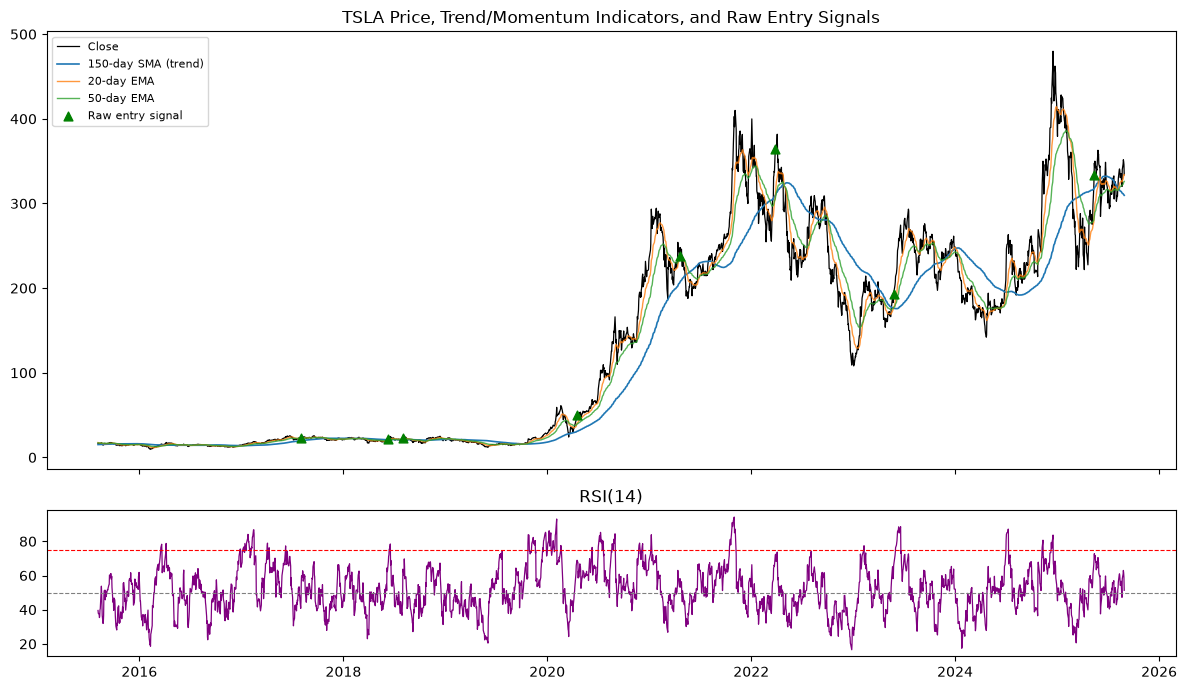

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(df.index, df["close"], label="Close", color="black", linewidth=0.9)
ax1.plot(df.index, df["sma_trend"], label="150-day SMA (trend)", linewidth=1.2)
ax1.plot(df.index, df["ema_fast"], label="20-day EMA", linewidth=1.0, alpha=0.8)
ax1.plot(df.index, df["ema_slow"], label="50-day EMA", linewidth=1.0, alpha=0.8)
entries = df[df["raw_entry"]]
ax1.scatter(entries.index, entries["close"], marker="^", color="green", s=40, zorder=5, label="Raw entry signal")
ax1.set_title("TSLA Price, Trend/Momentum Indicators, and Raw Entry Signals")
ax1.legend(loc="upper left", fontsize=8)

ax2.plot(df.index, df["rsi"], color="purple", linewidth=0.9)
ax2.axhline(75, color="red", linestyle="--", linewidth=0.8)
ax2.axhline(50, color="grey", linestyle="--", linewidth=0.8)
ax2.set_title("RSI(14)")

fig.tight_layout()
plt.show()

## 5. Save for Notebook 2

Following the same separation-of-concerns pattern as a research pipeline: signal generation is computationally separate from backtest simulation, so each can be iterated on independently.

In [12]:
df.to_pickle("tsla_signals.pkl")
print("Saved tsla_signals.pkl")

Saved tsla_signals.pkl
